In [1]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())

hostname = wifi-secure2-148.sri.ucl.ac.be
threads = 1
workers = 1
BLAS threads = 4


In [1]:
using Eliashberg
using CairoMakie

[ Info: Precompiling Eliashberg [adbadfb0-2f75-4cd8-9a77-6e8457d2b59b] (cache misses: include_dependency fsize change (2), mismatched flags (16))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


## 1D Tight-Binding model 

In [2]:
structure = atomic_chain(1) # 晶格常数 1.5 的一维链
kgrid = generate_kgrid(structure, 2000)

model = TightBinding(structure, 1.0, -0.3)

path = generate_kpath(structure; n_pts_per_segment=200)

KPath (1D, 201 points)

In [3]:
path.kpaths

1-element Vector{Vector{StaticArraysCore.SVector{1, Float64}}}:
 [[0.0], [0.015707963267948967], [0.031415926535897934], [0.047123889803846894], [0.06283185307179587], [0.07853981633974483], [0.09424777960769379], [0.10995574287564278], [0.12566370614359174], [0.1413716694115407]  …  [3.0002209841782523], [3.015928947446201], [3.03163691071415], [3.0473448739820994], [3.0630528372500483], [3.078760800517997], [3.094468763785946], [3.1101767270538954], [3.1258846903218442], [3.141592653589793]]

┌ Info: Calculate bands (KPath) started
│   • model : TightBinding (1D, 1 hoppings, EF=-0.3)
│   • kpath : KPath (1D, 201 points)
│   stage = "Calculate bands (KPath)"
│   status = :start
└   context = (model = TightBinding (1D, 1 hoppings, EF=-0.3), kpath = KPath (1D, 201 points))
┌ Info: Calculate bands (KPath) finished
│   • summary     : BandStructureData(1 bands, 201 k-points)
│   stage = "Calculate bands (KPath)"
│   status = :finish
│   elapsed_s = 0.304674625
│   context = (model = TightBinding (1D, 1 hoppings, EF=-0.3), kpath = KPath (1D, 201 points))
└   summary = BandStructureData(1 bands, 201 k-points)
┌ Info: Plot band structure started
│   • kpath   : KPath (1D, 201 points)
│   • n_bands : 1
│   • E_Fermi : 0.0
│   stage = "Plot band structure"
│   status = :start
└   context = (kpath = KPath (1D, 201 points), n_bands = 1, E_Fermi = 0.0)
┌ Info: Plot band structure finished
│   • figure_type : Figure
│   stage = "Plot band structure"
│   status = :finish
│   elapsed_s = 4

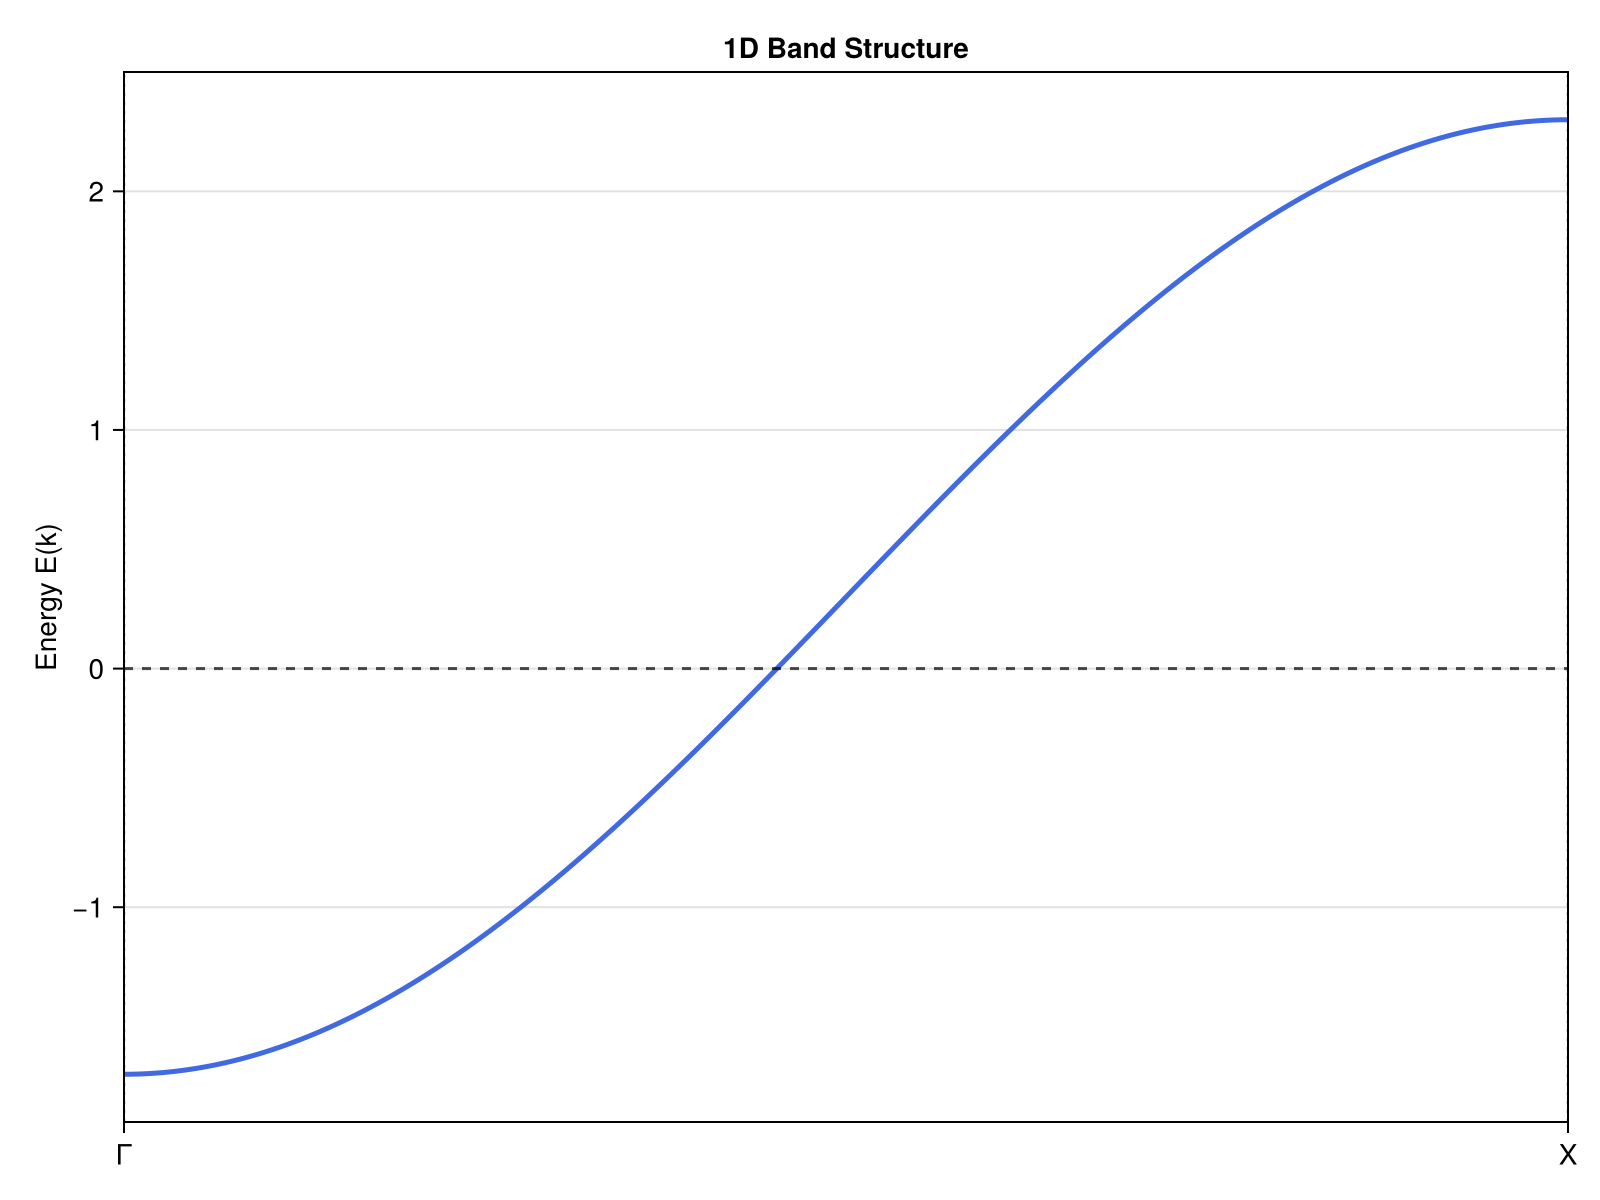

In [4]:
band_data = calculate_bands(model, path)
plot(band_data)
# save("tb_1d_eband.png", f)
# f


### Coulomb interaction

In [5]:
interaction = BareCoulombInteraction(0.01)

fluctuation = DirectChannel()
phis = range(0.0, 1.0, length=100)
Ts = range(0.1, 0.4, length=10)

omegas = range(0.0, 5.0, length=400)
T_plasmon = 0.01

0.01

In [6]:
# 对当前版本的包，等离激元示例直接展示裸密度响应的动态谱函数。
# 相互作用修正可以在后处理阶段进一步叠加到 χ₀(q, ω) 上。

spectral_function = scan_spectral_function(model, interaction, fluctuation, kgrid, path, omegas; T=T_plasmon, η=0.02)

┌ Info: Scan spectral function along path started
│   • model             : TightBinding (1D, 1 hoppings, EF=-0.3)
│   • interaction       : BareCoulombInteraction(cutoff=0.01)
│   • field             : Direct Channel
│   • kgrid             : KGrid (1D, 2000 points)
│   • qpath             : KPath (1D, 201 points)
│   • omegas            : 0.0:0.012531328320802004:5.0
│   • T                 : 0.01
│   • eta               : 0.02
│   • bootstrap_workers : false
│   • requested_workers : 0
│   stage = "Scan spectral function along path"
│   status = :start
└   context = (model = TightBinding (1D, 1 hoppings, EF=-0.3), interaction = BareCoulombInteraction(cutoff=0.01), field = Direct Channel, kgrid = KGrid (1D, 2000 points), qpath = KPath (1D, 201 points), omegas = 0.0:0.012531328320802004:5.0, T = 0.01, eta = 0.02, bootstrap_workers = false, requested_workers = 0)
┌ Info: Scan RPA spectral function started
│   • model             : TightBinding (1D, 1 hoppings, EF=-0.3)
│   • interactio

201×400 Matrix{Float64}:
  0.0          0.0          …  0.0         0.0         0.0
  7.39524e-22  1.97268e-7      4.79796e-8  4.76307e-8  4.72851e-8
 -8.2155e-22   7.96447e-7      1.91951e-7  1.90555e-7  1.89172e-7
 -1.4203e-20   1.82017e-6      4.32011e-7  4.28868e-7  4.25756e-7
 -5.42436e-20  3.30795e-6      7.68323e-7  7.62732e-7  7.57194e-7
  5.47855e-20  5.31901e-6   …  1.20111e-6  1.19237e-6  1.18371e-6
  1.6876e-19   7.93688e-6      1.73068e-6  1.71807e-6  1.70558e-6
  9.36954e-20  1.12761e-5      2.35737e-6  2.34019e-6  2.32317e-6
  1.77095e-19  1.5492e-5       3.08162e-6  3.05913e-6  3.03687e-6
  1.48148e-19  2.07955e-5      3.9039e-6   3.8754e-6   3.84717e-6
 -2.04309e-19  2.74748e-5   …  4.82478e-6  4.78952e-6  4.75459e-6
 -1.22188e-19  3.59278e-5      5.84487e-6  5.8021e-6   5.75975e-6
 -4.21151e-19  4.67132e-5      6.96485e-6  6.91383e-6  6.8633e-6
  ⋮                         ⋱                          
 -3.85661e-18  0.000395565     0.00321865  0.00315572  0.0030947
 -8.

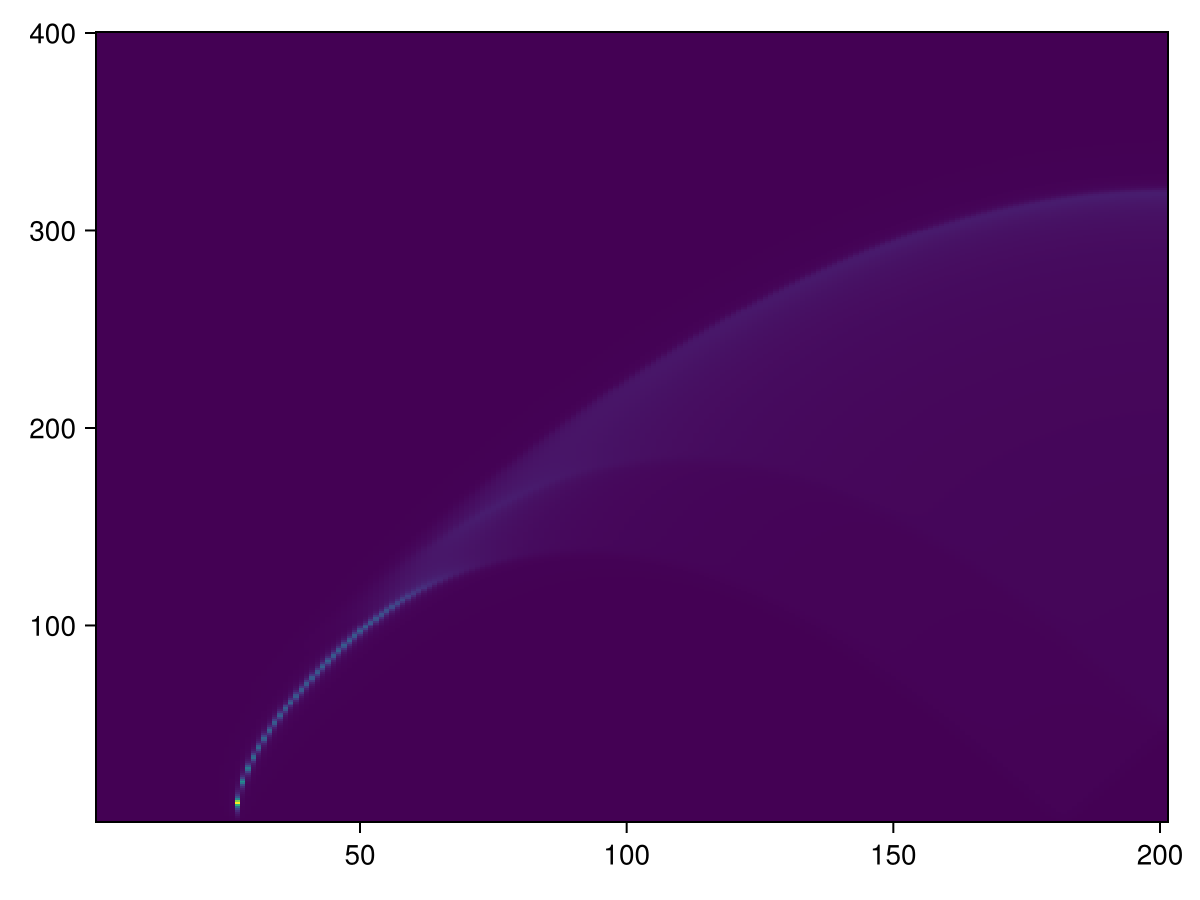

In [7]:
plot(spectral_function)

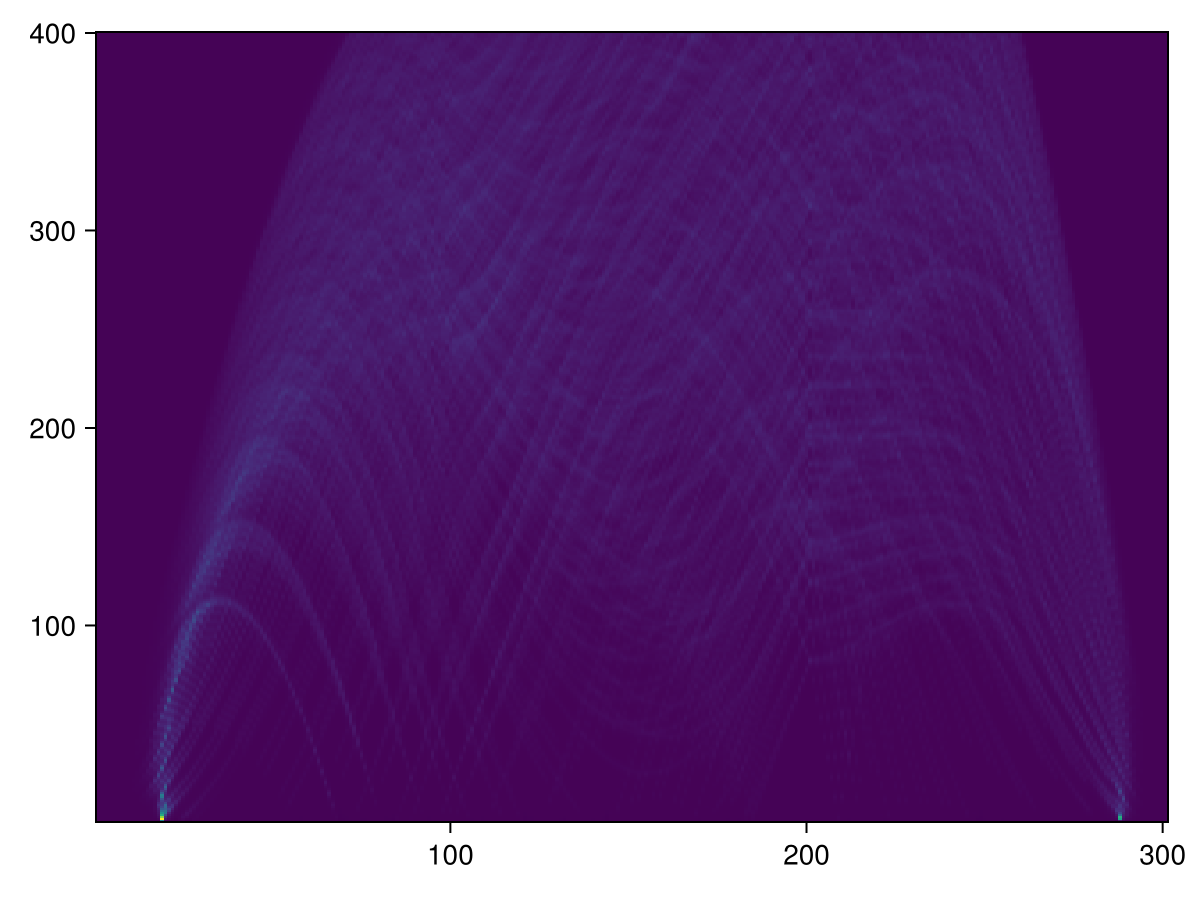

CairoMakie.Screen{IMAGE}


In [6]:
spectraldata = load("/Users/yimingzhang/Developer/theory/Eliashberg/examples/plasmon/out/plasmon_2d_20260415_232327/plasmon_scan.jld2")

fig_plasmon = plot(spectraldata)
display(fig_plasmon)

In [ ]:
band_data = compute_renormalized_band_data(Ts, fluctuation, tb, interaction, kgrid, path)

RenormalizedBandData{1}(KPath{1}(StaticArraysCore.SVector{1, Float64}[[0.0], [0.010471975511965976], [0.020943951023931952], [0.03141592653589793], [0.041887902047863905], [0.05235987755982988], [0.06283185307179585], [0.07330382858376185], [0.08377580409572781], [0.09424777960769379]  …  [2.0001473227855016], [2.0106192982974673], [2.0210912738094335], [2.0315632493213993], [2.0420352248333655], [2.0525072003453313], [2.0629791758572975], [2.0734511513692633], [2.0839231268812295], [2.0943951023931953]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201], ["Γ", "X"]), [-1.7, -1.6997532649633211, -1.6990131207314632, -1.69777974992394, -1.696053456856543, -1.6938346674662559, -1.69112392920616, -1.6879219109103594, -1.6842294026289557, -1.680047315433115  …  2.280047315433115, 2.2842294026289554, 2.287921910910359, 2.29112392920616, 2.293834667466256, 2.296053456856543, 2.29777974992394, 2.299013120731463, 2.299753264963321

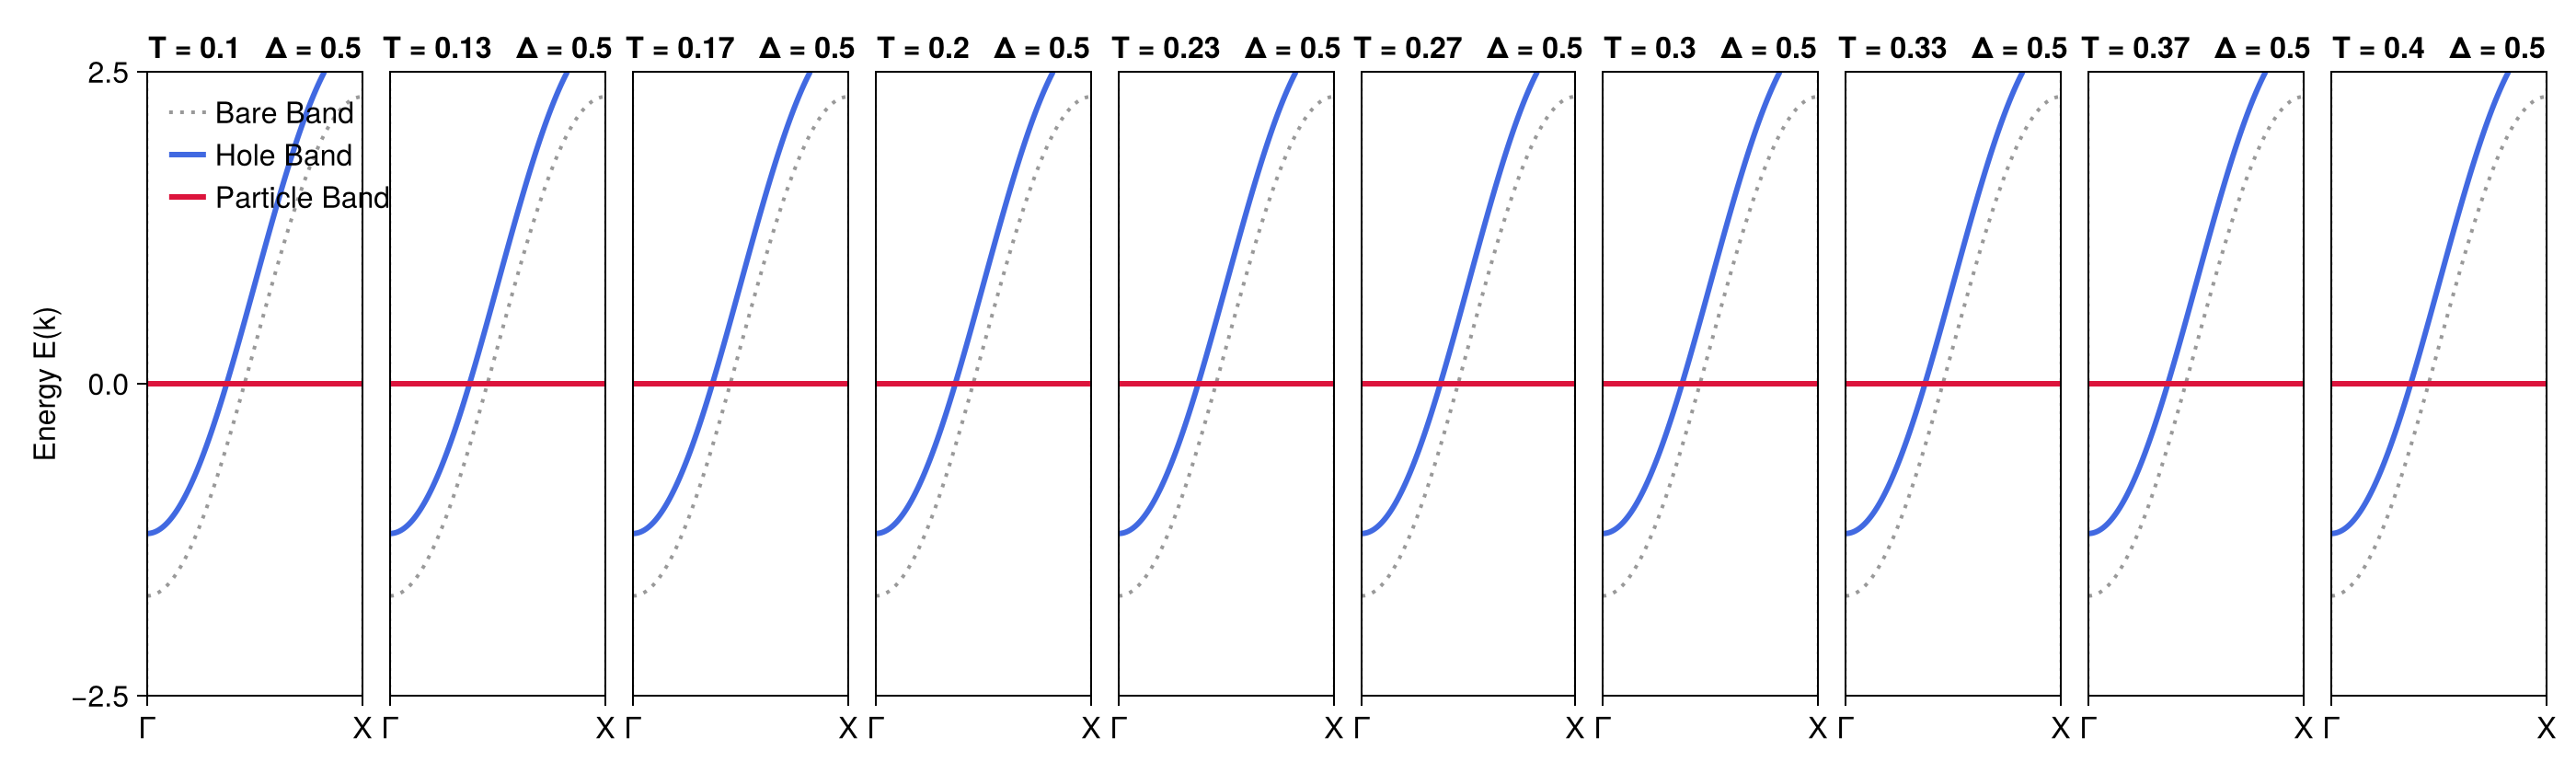

In [ ]:
plot(band_data)

## 2D Tight-Binding model 

In [3]:
lattice= SquareLattice(1.5) # 晶格常数 1.5 的二维正方晶格
kgrid = generate_reciprocal_lattice(lattice, 50, 50)

tb = TightBinding(lattice, 1.0, -0.3)

path = generate_kpath(lattice, n_pts_per_segment=200)

KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.010471975511965976, 0.0], [0.020943951023931952, 0.0], [0.03141592653589793, 0.0], [0.041887902047863905, 0.0], [0.05235987755982988, 0.0], [0.06283185307179585, 0.0], [0.07330382858376185, 0.0], [0.08377580409572781, 0.0], [0.09424777960769379, 0.0]  …  [0.0942477796076937, 0.0942477796076937], [0.08377580409572793, 0.08377580409572793], [0.07330382858376172, 0.07330382858376172], [0.06283185307179595, 0.06283185307179595], [0.05235987755982974, 0.05235987755982974], [0.04188790204786397, 0.04188790204786397], [0.031415926535897754, 0.031415926535897754], [0.020943951023931984, 0.020943951023931984], [0.01047197551196577, 0.01047197551196577], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201, 401, 601], ["Γ", "X", "M", "Γ"])

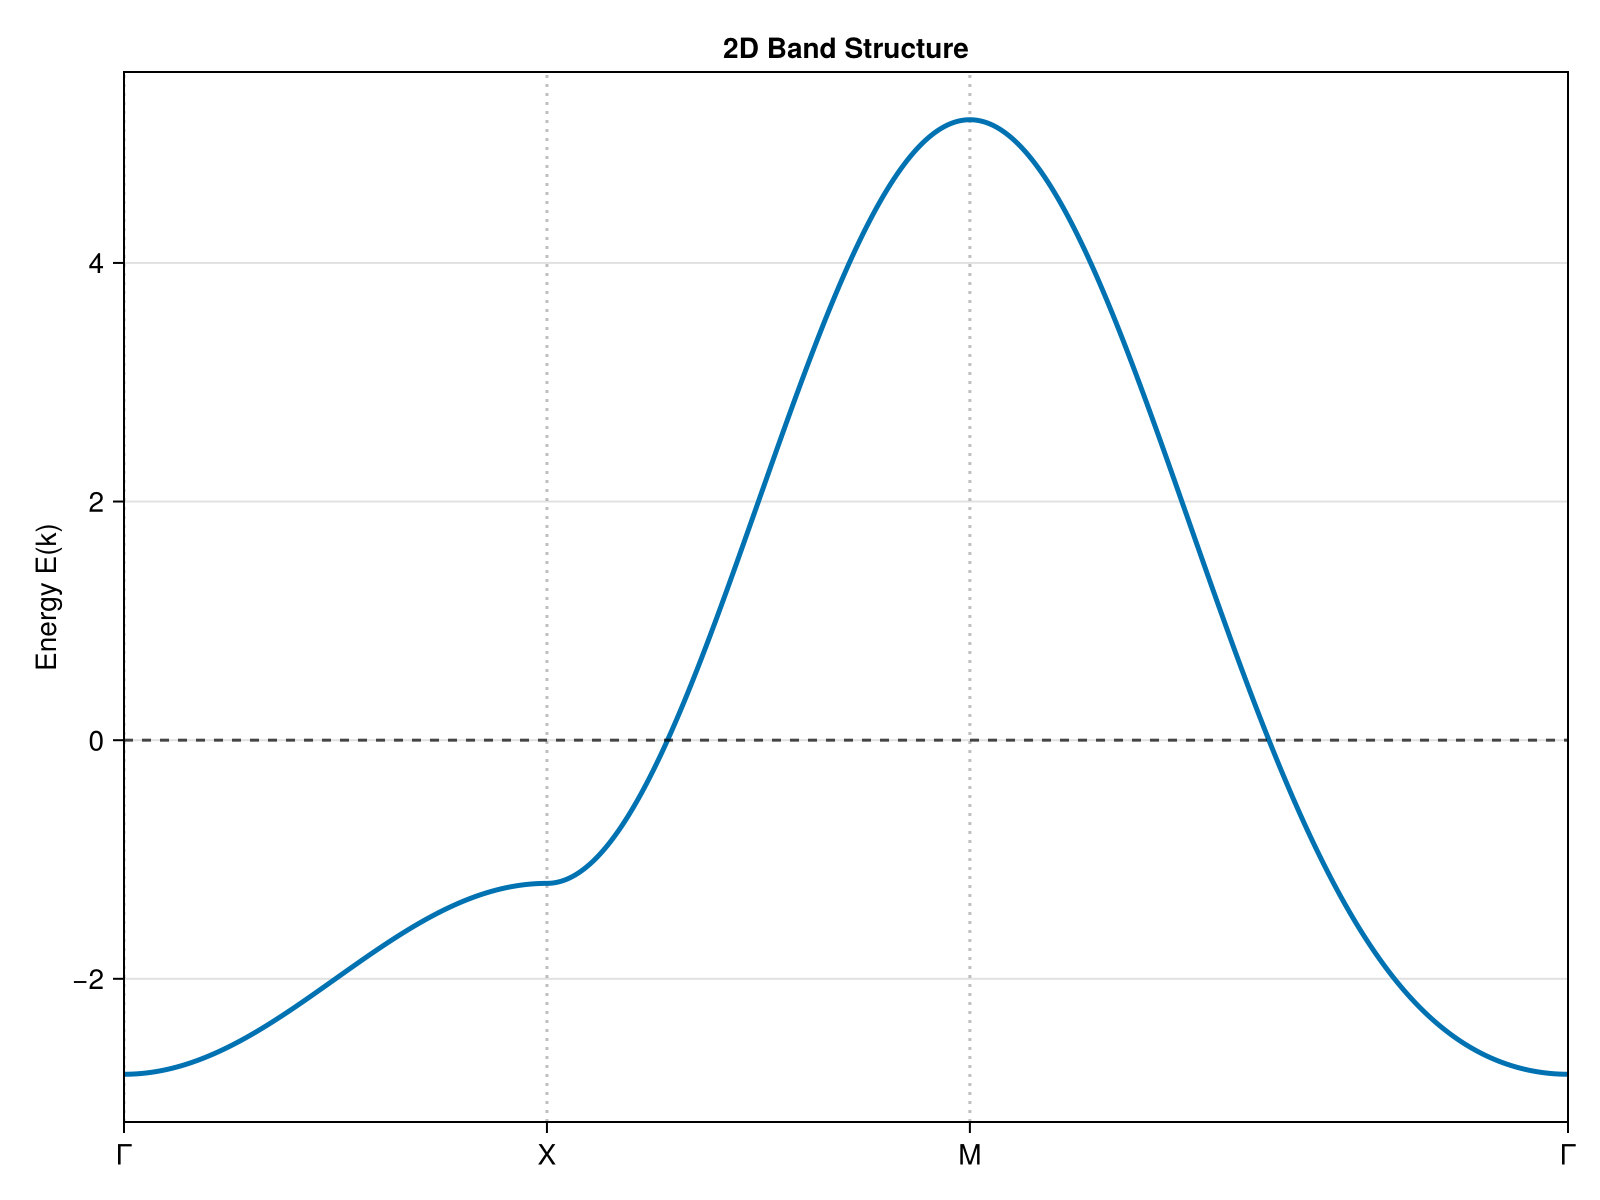

In [4]:
band_data = compute_band_data(tb, path)
f = plot(band_data)
save("tb_1d_eband.png", f)
f


### Coulomb interaction

In [9]:
interaction = BareCoulombInteraction(0.01)

fluctuation = DirectChannel()
phis = range(0.0, 1.0, length=100)
Ts = range(0.1, 0.4, length=6)

omegas = range(0.0, 5.0, length=400)
T_plasmon = 0.01

0.01

In [10]:
band_data = compute_renormalized_band_data(Ts, fluctuation, tb, interaction, kgrid, path)

RenormalizedBandData{2}(KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.010471975511965976, 0.0], [0.020943951023931952, 0.0], [0.03141592653589793, 0.0], [0.041887902047863905, 0.0], [0.05235987755982988, 0.0], [0.06283185307179585, 0.0], [0.07330382858376185, 0.0], [0.08377580409572781, 0.0], [0.09424777960769379, 0.0]  …  [0.0942477796076937, 0.0942477796076937], [0.08377580409572793, 0.08377580409572793], [0.07330382858376172, 0.07330382858376172], [0.06283185307179595, 0.06283185307179595], [0.05235987755982974, 0.05235987755982974], [0.04188790204786397, 0.04188790204786397], [0.031415926535897754, 0.031415926535897754], [0.020943951023931984, 0.020943951023931984], [0.01047197551196577, 0.01047197551196577], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201, 401, 601], ["Γ", "X", "M", "Γ"]), [-2.8; -2.7999013059853284; … ; -2.7998025937072035; -2.8;;], [-2.3; -2.2999013059853284; … ; -2.2998

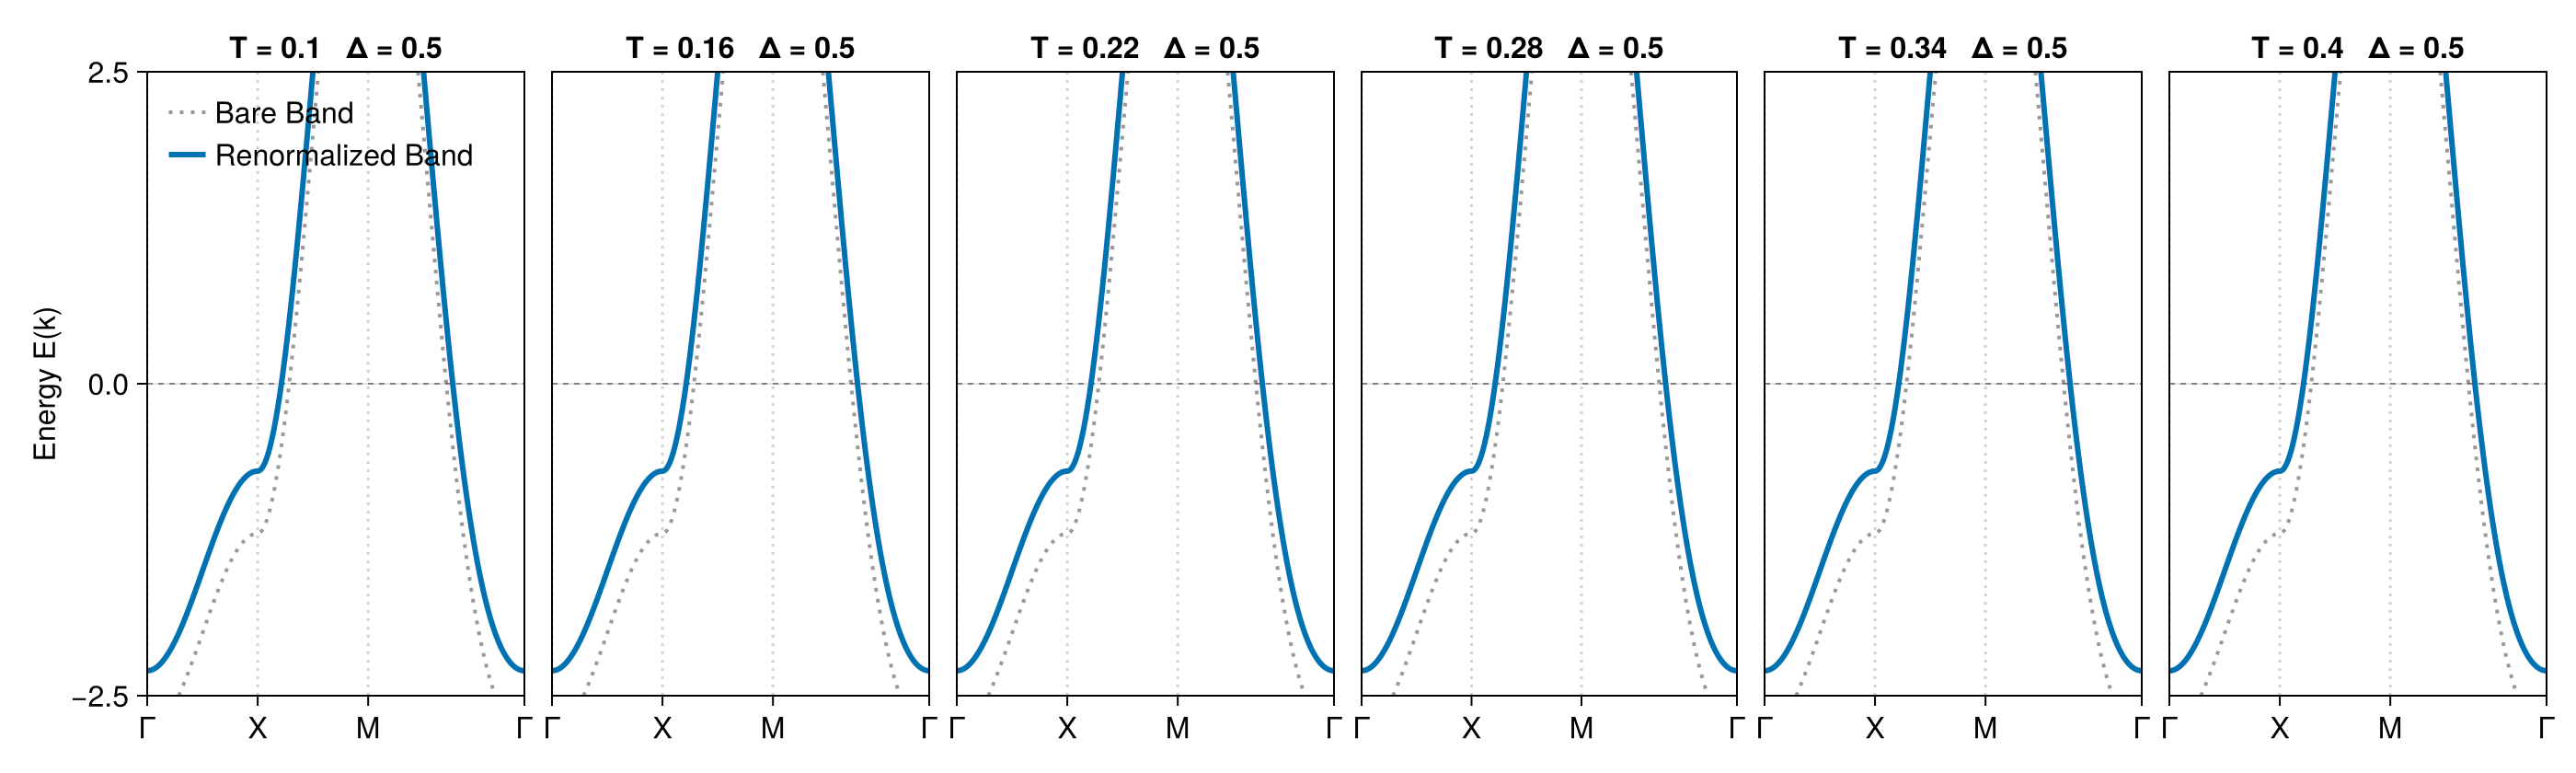

In [11]:
plot(band_data)

In [ ]:
# 对当前版本的包，等离激元示例直接展示裸密度响应的动态谱函数。
# 相互作用修正可以在后处理阶段进一步叠加到 χ₀(q, ω) 上。

spectral_matrix = load("/Users/yimingzhang/Developer/theory/Eliashberg/results/plasmon_2d_20260413_230236/plasmon_scan.jld2")

SpectralMapData{2}(KPath (2D, 1501 points, 1 branches, labels=["Γ", "X", "M"]), [0.0, 0.01002004008016032, 0.02004008016032064, 0.03006012024048096, 0.04008016032064128, 0.050100200400801605, 0.06012024048096192, 0.07014028056112225, 0.08016032064128256, 0.09018036072144289  …  4.909819639278557, 4.919839679358717, 4.929859719438878, 4.939879759519038, 4.949899799599199, 4.959919839679359, 4.969939879759519, 4.979959919839679, 4.98997995991984, 5.0], [0.0 0.0 … 0.0 0.0; 0.01035701693451695 0.038268986653423584 … 2.4565392858259497e-7 2.446527174187335e-7; … ; 0.006410560474300624 0.03497659860712022 … 3.265185805680418e-7 3.251773111047941e-7; 0.0 0.0 … 0.0 0.0], 0.0, nothing, 0.01)

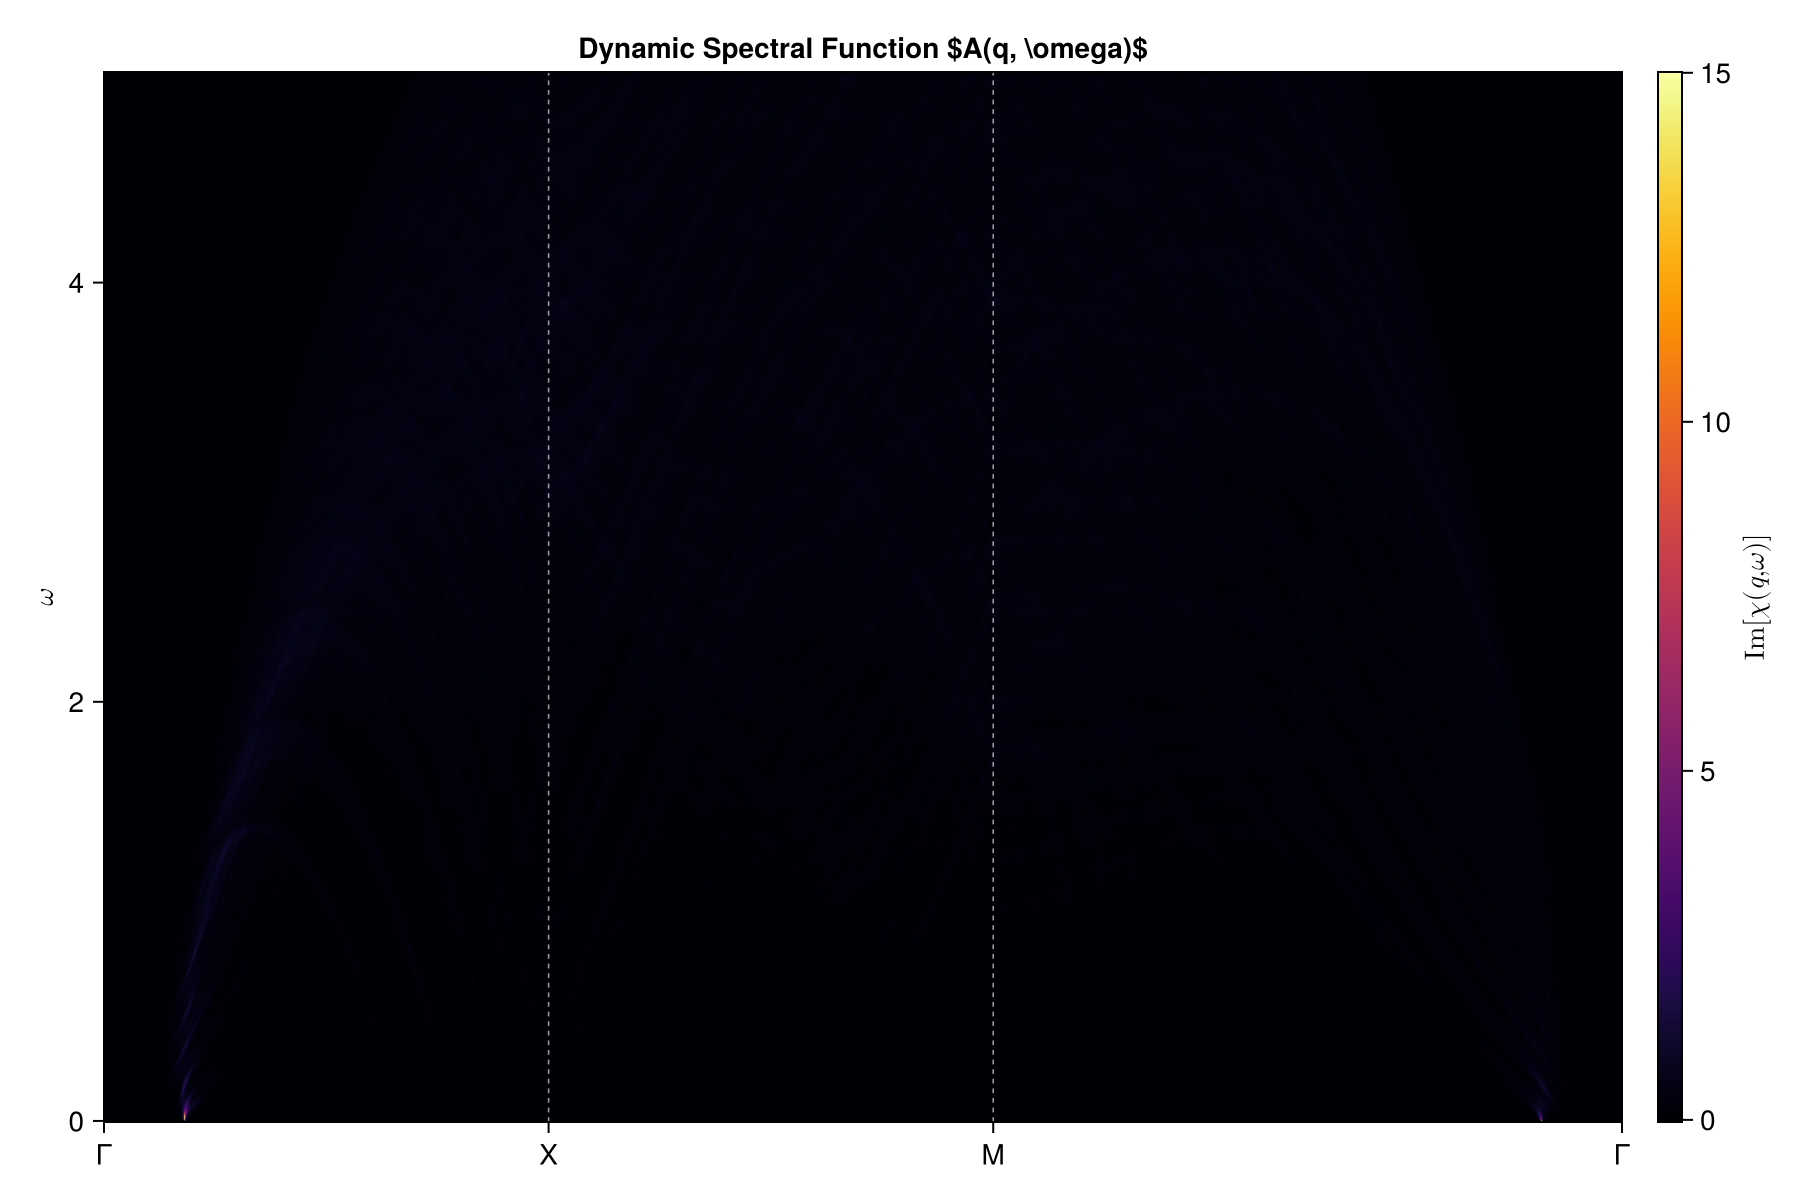

In [ ]:
# plot_result_file("/Users/yimingzhang/Developer/theory/Eliashberg/results/plasmon_2d_20260413_112553/plasmon_scan.jld2"; mode=:spectral)
plot(spectral_matrix)